In [74]:
import sys, os
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [75]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna.distributions")

In [76]:
import numpy as np
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [77]:
# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [78]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

In [79]:
np.unique(cell_ids).shape

(247,)

In [80]:
# ============================
# BATCH CONTROL (manual)
# ============================

CELLS_PER_BATCH = 25  # how many cells to include per run
BATCH_INDEX = 0  # manually change this: 0, 1, 2, ...

# Compute batches from the full set of cell IDs
unique_cells = np.unique(cell_ids)
batches = [
    unique_cells[i : i + CELLS_PER_BATCH]
    for i in range(0, len(unique_cells), CELLS_PER_BATCH)
]

# Select the batch you want to run
CURRENT_BATCH_CELLS = batches[BATCH_INDEX]

mask = np.isin(cell_ids, CURRENT_BATCH_CELLS)

X = X[:, mask]
Y = Y[mask]
cell_ids = cell_ids[mask]
rec_ids = rec_ids[mask]

In [81]:
BASE_MODEL_DIR = f"../resources/models/real/batch_{BATCH_INDEX}"
BASE_RESULTS_DIR = f"../resources/results/real/batch_{BATCH_INDEX}"
LOG_PATH = os.path.join(Path(BASE_RESULTS_DIR), f"batch_log_{BATCH_INDEX}.txt")

FORCE_EXPERIMENTS = False

In [82]:
def log_print(*args, **kwargs):
    """Print to console AND append to batch log file."""
    text = " ".join(str(a) for a in args)

    # Print to console
    print(text, **kwargs)

    # Append to log file
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(text + "\n")

In [83]:
# Ensure the batch directory exists BEFORE creating the log file
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# Create the log file only if it doesn't exist
if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write(f"Batch {BATCH_INDEX} Log File\n")
        f.write(f"Created: {datetime.now()}\n")
        f.write("="*60 + "\n\n")

In [84]:

log_print(f"Running batch {BATCH_INDEX+1}/{len(batches)}")
log_print(f"Cells in this batch: {CURRENT_BATCH_CELLS}")

log_print("Filtered dataset shape:", X.shape, Y.shape)
log_print("Unique cells in this batch:", np.unique(cell_ids))

Running batch 1/10
Cells in this batch: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]
Filtered dataset shape: (14, 155750) (155750,)
Unique cells in this batch: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


### Baseline models (GLM and XGBoost)

In [ ]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== GLM Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.1208
Train log-likelihood:  -3924.89
Train deviance:        1.45
Val pseudo-R²:         -0.0267
Val log-likelihood:    -884.85
Val deviance:          1.20
Test pseudo-R²:        -0.0083
Test log-likelihood:   -919.17
Test deviance:         1.22

--- Cell 2 ---
Train pseudo-R²:       0.1369
Train log-likelihood:  -3744.74
Train deviance:        0.92
Val pseudo-R²:         0.1577
Val log-likelihood:    -842.23
Val deviance:          0.93
Test pseudo-R²:        0.1213
Test log-likelihood:   -868.11
Test deviance:         0.94

--- Cell 3 ---
Train pseudo-R²:       0.1216
Train log-likelihood:  -2986.20
Train deviance:        0.78
Val pseudo-R²:         -0.1937
Val log-likelihood:    -993.90
Val deviance:          1.41
Test pseudo-R²:        -0.0859
Test log-likelihood:   -900.04
Test deviance:         1.11

--- Cell 4 ---
Train pseudo-R²:       0.1733
Train log-likelihood:  -3234.94
Train deviance:        1.26
Val pseudo-R²

In [86]:
glm_results["best_params"]

{1: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 2: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 4: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 5: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 6: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 7: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 8: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 9: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 10: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 11: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12: {'model_params': {'alpha': 0.0}, 'trainer_params': {}},
 13: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 15: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 16: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 17: {'model_params': {'alph

In [ ]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)


===== XGBoost Summary =====

--- Cell 1 ---
Train pseudo-R²:       0.3412
Train log-likelihood:  -3134.92
Train deviance:        1.08
Val pseudo-R²:         0.0009
Val log-likelihood:    -869.80
Val deviance:          1.17
Test pseudo-R²:        0.0535
Test log-likelihood:   -884.13
Test deviance:         1.15

--- Cell 2 ---
Train pseudo-R²:       0.2458
Train log-likelihood:  -3491.88
Train deviance:        0.80
Val pseudo-R²:         0.2375
Val log-likelihood:    -801.22
Val deviance:          0.84
Test pseudo-R²:        0.1779
Test log-likelihood:   -839.75
Test deviance:         0.88

--- Cell 3 ---
Train pseudo-R²:       0.3223
Train log-likelihood:  -2599.56
Train deviance:        0.60
Val pseudo-R²:         0.0995
Val log-likelihood:    -832.16
Val deviance:          1.06
Test pseudo-R²:        0.1436
Test log-likelihood:   -789.98
Test deviance:         0.88

--- Cell 4 ---
Train pseudo-R²:       0.3568
Train log-likelihood:  -2627.07
Train deviance:        0.98
Val pseudo-R²

In [88]:
xgboost_results["best_params"]

{1: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 2: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 3: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 4: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 5: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 6: {'model_params': {'learning_rate': 0.05,
   'max_depth': 4,
   'n_estimators': 200},
  'trainer_params': {}},
 7: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 8: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 9: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},

### Extractor factory

In [89]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS)

In [90]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===


[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-PerCell-MLP.pkl

=== Per-Cell NN (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-PerCell-CNN.pkl

=== Per-Cell NN (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-PerCell-RNN.pkl


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


In [91]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS)

In [92]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedShallowHead-TL-MLP.pkl

=== TL DeepSharedShallowHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedShallowHead-TL-CNN.pkl

=== TL DeepSharedShallowHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedShallowHead-TL-RNN.pkl


### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [93]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedDeepHead-TL-MLP.pkl

=== TL DeepSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedDeepHead-TL-CNN.pkl

=== TL DeepSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-DeepSharedDeepHead-TL-RNN.pkl


### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [94]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": [None],  # ignored for CNN/RNN, but required for MLP
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-ShallowSharedDeepHead-TL-MLP.pkl

=== TL ShallowSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-ShallowSharedDeepHead-TL-CNN.pkl

=== TL ShallowSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_0\NN-ShallowSharedDeepHead-TL-RNN.pkl


In [95]:
print("MLP\n", percell_results["MLP"]["GS"]["best_params"])
print("CNN\n", percell_results["CNN"]["GS"]["best_params"])
print("RNN\n", percell_results["RNN"]["GS"]["best_params"])

MLP
 {1: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 1e-05}}, 2: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 3: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 4: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 5: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 6: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.001}}, 7: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 8: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 9: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0}}, 10: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0}}, 11: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0001}}, 12: {'model_params': {'hidden_si

In [96]:
print("MLP\n", tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'hidden_sizes': (256, 128), 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05,

In [97]:
print("MLP\n", tl_results["deep_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': None, 'shared_sizes': (256, 128)}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
), 'shared_sizes': None}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dro

In [98]:
print("MLP\n", tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (64, 32), 'shared_dim': 256, 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)}, 'trainer_params': {'l1_lambda': 0.0001}}


### Build comparison lists for GS

In [99]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [100]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,1,-0.008305,0.053484,0.021697,-0.079348,-0.054452,0.009188,0.082151,-0.005557,0.061126,0.092165,0.018444,0.013549,0.008946,0.026181
1,2,0.121348,0.177876,0.186043,0.109085,-0.009834,0.203070,0.186865,0.137167,0.199585,0.184275,0.141035,0.199880,0.159723,0.128892
2,3,-0.085893,0.143645,0.084490,0.037189,0.105782,0.105139,0.129902,0.038226,0.162701,0.146991,0.076718,0.094248,0.077174,0.072442
3,4,-0.083061,0.152777,0.133414,0.058297,0.169333,0.167300,0.197938,0.144160,0.196657,0.204279,0.175304,0.176800,0.137264,0.167885
4,5,0.132449,0.197943,0.177141,-0.159784,0.102195,0.280341,0.283374,0.218374,0.295984,0.265061,0.204297,0.276670,0.235840,0.185022
5,6,0.214766,0.218314,0.210825,0.043882,0.017284,0.238288,0.176947,0.010920,0.221339,0.126993,0.059994,0.226201,0.053215,0.042412
6,7,0.006153,0.063487,0.077247,0.060652,-0.009763,0.101999,0.102691,0.037600,0.116541,0.109417,0.070782,0.103068,0.067784,0.056666
7,8,0.080103,0.097034,0.083594,-0.006451,-0.037920,0.092463,0.077170,-0.003221,0.099954,0.053965,0.016048,0.090628,0.014337,0.017135
8,9,-0.093847,-0.200888,-0.115486,-0.169067,-0.043584,-0.109235,-0.055262,-0.082193,-0.097938,-0.060154,-0.035186,-0.089889,-0.097421,-0.038997
9,10,0.224288,0.283650,0.272556,0.180201,0.153367,0.347476,0.268759,0.200389,0.366928,0.291693,0.189489,0.363255,0.138524,0.189652


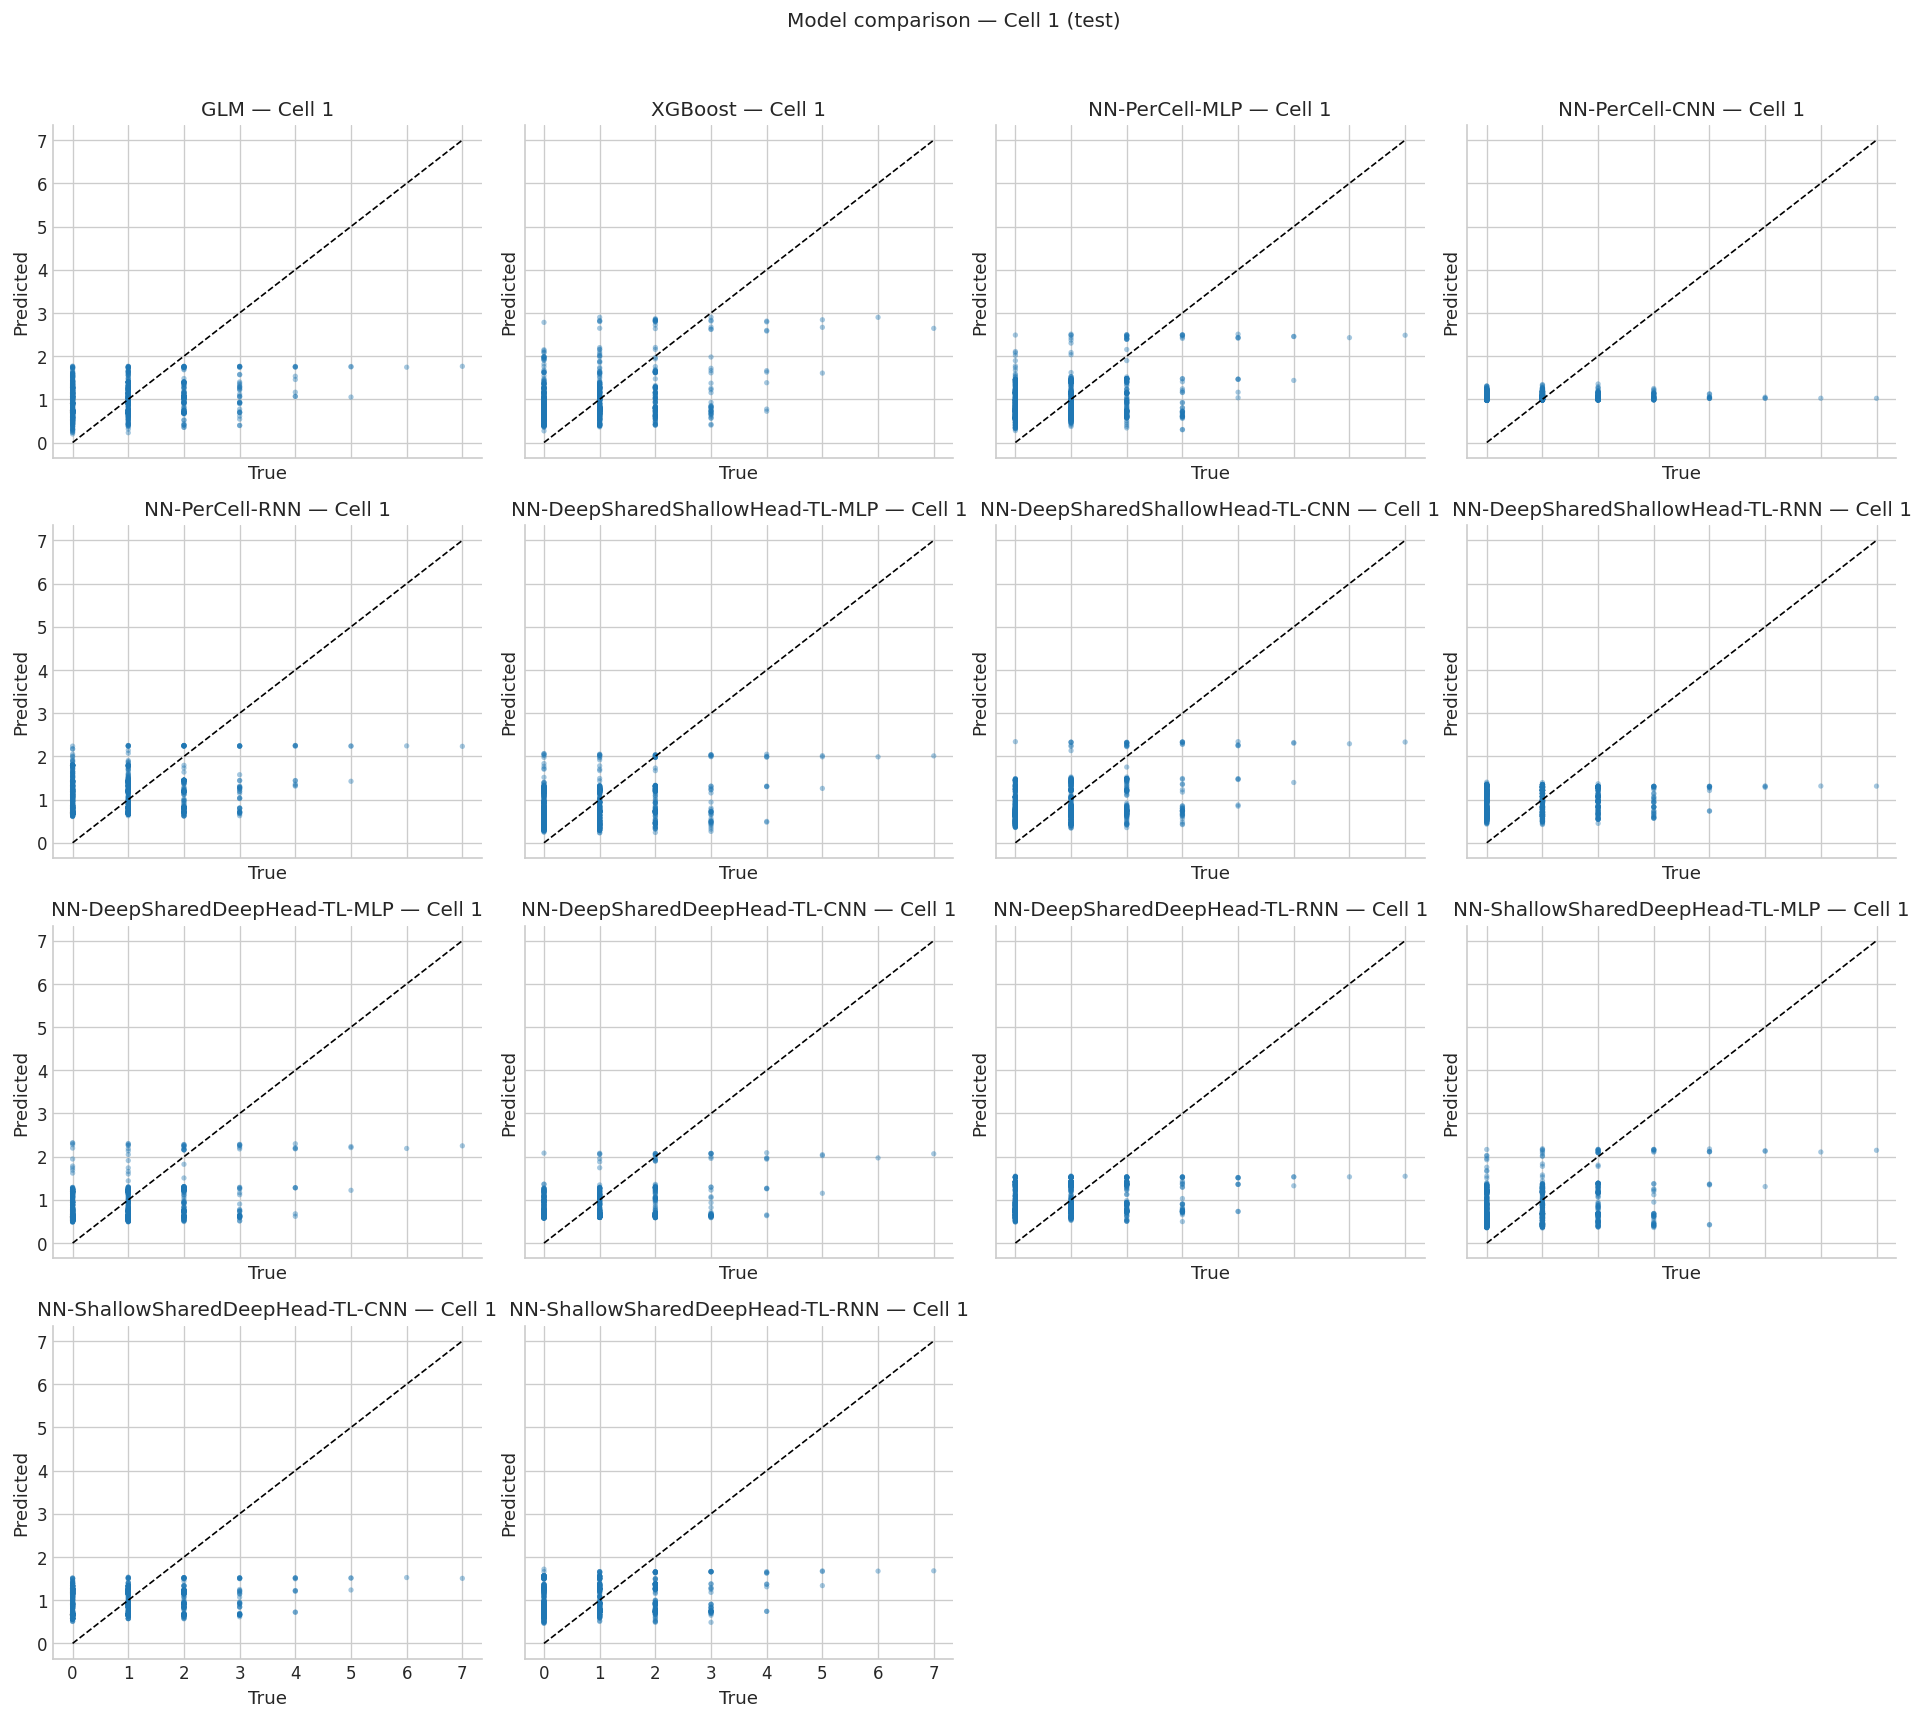

In [101]:
compare_models_for_cell(model_results_gs, cell=1, split="test")

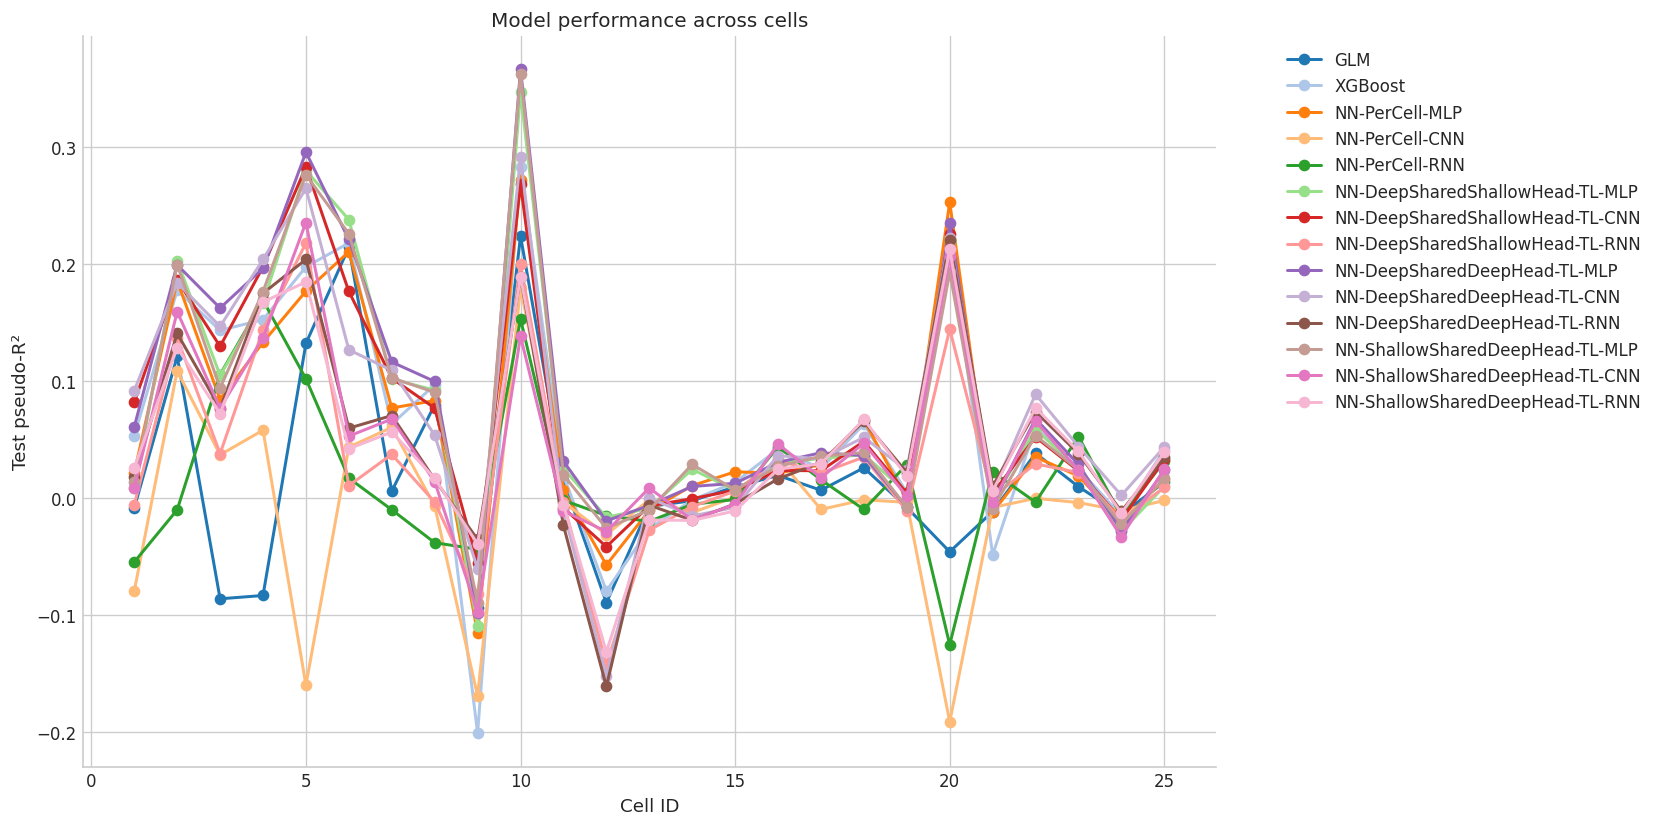

In [102]:
compare_r2_across_cells(model_results_gs, split="test")

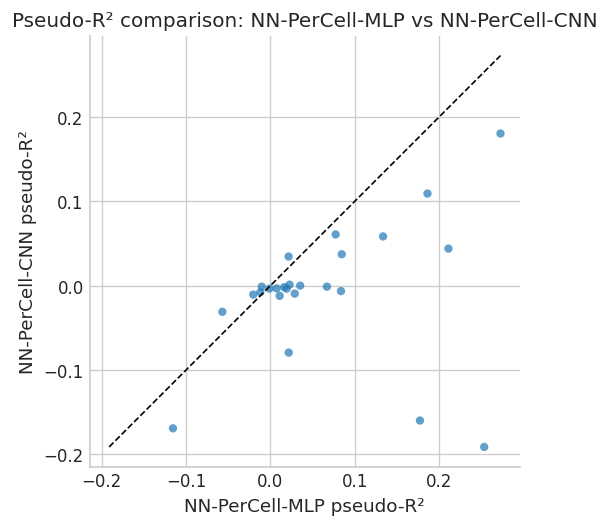

In [103]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [104]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
log_print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    log_print(f"  {p}")

Generated 117 plots
  ..\resources\results\real\batch_0\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-CNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
